In [1]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & DATASET INGESTION (loan_default_nn.csv)
# Run this cell first. Installs/imports TensorFlow and creates the dataset.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.size"] = 10

print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")

# ------------------------------------------------------------------------------
# Generate Synthetic Tabular Loan Default Dataset (3,000 instances)
# ------------------------------------------------------------------------------
np.random.seed(42)
N = 3000

credit_score = np.random.normal(loc=650, scale=80, size=N).clip(300, 850)
annual_income = np.random.lognormal(mean=10.8, sigma=0.6, size=N).clip(20000, 300000)
loan_amount = np.random.normal(loc=25000, scale=12000, size=N).clip(2000, 80000)
debt_to_income = (loan_amount / annual_income) * np.random.uniform(0.8, 1.4, size=N)
employment_years = np.random.exponential(scale=6, size=N).clip(0, 40).astype(int)
missed_payments_2yr = np.random.poisson(lam=0.8, size=N)

# Complex non-linear default risk probability
risk_logits = (
    1.2
    - 0.008 * credit_score
    - 0.000015 * annual_income
    + 0.00004 * loan_amount
    + 3.2 * debt_to_income
    - 0.08 * employment_years
    + 0.95 * missed_payments_2yr
    + 0.0001 * (loan_amount * debt_to_income) # Non-linear interaction
)
default_prob = 1 / (1 + np.exp(-risk_logits))
default_label = np.where(np.random.rand(N) < default_prob, 1, 0)

df_loan = pd.DataFrame({
    "Credit_Score": np.round(credit_score, 0),
    "Annual_Income_USD": np.round(annual_income, 2),
    "Loan_Amount_USD": np.round(loan_amount, 2),
    "Debt_to_Income_Ratio": np.round(debt_to_income, 4),
    "Employment_Years": employment_years,
    "Missed_Payments_2Yr": missed_payments_2yr,
    "Default": default_label
})

df_loan.to_csv("loan_default_nn.csv", index=False)
print("✅ Dataset 'loan_default_nn.csv' generated!")
print(f"Total Rows: {len(df_loan):,} | Default Rate (Class 1): {df_loan['Default'].mean()*100:.2f}%")
display(df_loan.head(3))

TensorFlow Version: 2.20.0
NumPy Version: 2.1.3
✅ Dataset 'loan_default_nn.csv' generated!
Total Rows: 3,000 | Default Rate (Class 1): 48.33%


,Credit_Score,Annual_Income_USD,Loan_Amount_USD,Debt_to_Income_Ratio,Employment_Years,Missed_Payments_2Yr,Default
0,690.0,20000.00,11631.02,0.7317,15,0,0
1,639.0,29253.92,17428.83,0.7226,0,1,1
2,702.0,38247.62,13695.28,0.3558,8,3,0


In [2]:
# ==============================================================================
# SECTION 1: BIOLOGICAL INSPIRATION, THE PERCEPTRON & NETWORK ANATOMY
# ==============================================================================
"""
1. BIOLOGICAL VS. ARTIFICIAL NEURON:
   ┌──────────────────────┬────────────────────────────────────────────────────────┐
   │ Biological Component │ Artificial Neural Network (ANN) Equivalent             │
   ├──────────────────────┼────────────────────────────────────────────────────────┤
   │ Dendrites            │ Input Features (x₁, x₂, ..., x_p)                      │
   │ Synapse Strength     │ Learned Connection Weights (w₁, w₂, ..., w_p)          │
   │ Cell Body (Soma)     │ Summation Junction + Bias: z = Σ(w_i * x_i) + b        │
   │ Axon / Threshold     │ Activation Function: a = σ(z)                          │
   │ Axon Terminals       │ Output Transmission to Downstream Neurons              │
   └──────────────────────┴────────────────────────────────────────────────────────┘

2. ROSENBLATT'S PERCEPTRON (1958):
   - The fundamental building block of neural networks:
     ŷ = f( z ) = f( w₁x₁ + w₂x₂ + ... + w_p x_p + b ) = f( WᵀX + b )
   - A single perceptron can only solve linearly separable problems (it failed on XOR).
   - MULTI-LAYER PERCEPTRONS (MLPs) stack perceptrons with non-linear activation
     functions, making them Universal Function Approximators.

3. NETWORK ANATOMY TERMS:
   - INPUT LAYER: Receives raw features (does not perform computation; size = number of features).
   - HIDDEN LAYERS: Intermediate feature representations that extract increasingly abstract patterns.
   - OUTPUT LAYER: Produces final task predictions (e.g., 1 neuron for binary classification / regression).
   - NEURON / NODE: A single computational unit executing: a = Activation( WᵀX + b ).
   - WEIGHTS (W): Multiplicative parameters determining the strength and direction of feature influence.
   - BIAS (b): Additive parameter that shifts the activation function along the horizontal axis (like y-intercept).
"""

"\n1. BIOLOGICAL VS. ARTIFICIAL NEURON:\n   ┌──────────────────────┬────────────────────────────────────────────────────────┐\n   │ Biological Component │ Artificial Neural Network (ANN) Equivalent             │\n   ├──────────────────────┼────────────────────────────────────────────────────────┤\n   │ Dendrites            │ Input Features (x₁, x₂, ..., x_p)                      │\n   │ Synapse Strength     │ Learned Connection Weights (w₁, w₂, ..., w_p)          │\n   │ Cell Body (Soma)     │ Summation Junction + Bias: z = Σ(w_i * x_i) + b        │\n   │ Axon / Threshold     │ Activation Function: a = σ(z)                          │\n   │ Axon Terminals       │ Output Transmission to Downstream Neurons              │\n   └──────────────────────┴────────────────────────────────────────────────────────┘\n\n2. ROSENBLATT'S PERCEPTRON (1958):\n   - The fundamental building block of neural networks:\n     ŷ = f( z ) = f( w₁x₁ + w₂x₂ + ... + w_p x_p + b ) = f( WᵀX + b )\n   - A single perce

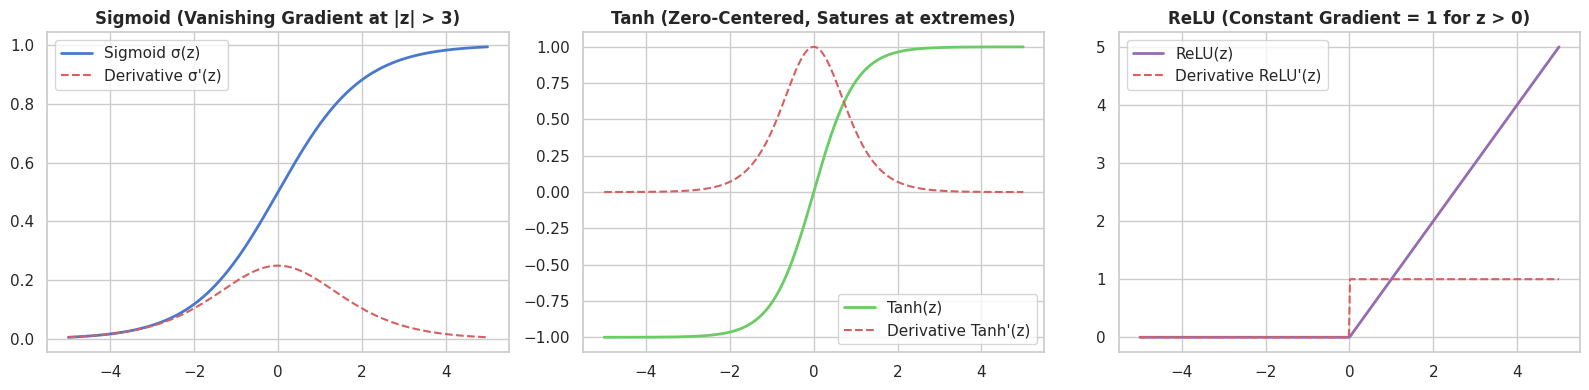

In [3]:
# ==============================================================================
# SECTION 2: ACTIVATION FUNCTIONS & THE VANISHING GRADIENT PROBLEM
# ==============================================================================
"""
WHY DO WE NEED ACTIVATION FUNCTIONS?
Without non-linear activation functions, stacking 100 dense layers is mathematically
equivalent to a SINGLE linear regression: W₃(W₂ (W₁X + b₁) + b₂) + b₃ = W_net X + b_net.
Activation functions introduce non-linearity, allowing networks to learn complex curves.

KEY ACTIVATION FUNCTIONS:
1. SIGMOID: σ(z) = 1 / (1 + e^(-z))
   - Range: (0, 1)
   - Usage: Output layer for Binary Classification.
   - Flaw: Satures at extreme ±z, driving derivative σ'(z) -> 0 (Vanishing Gradient).

2. TANH (Hyperbolic Tangent): tanh(z) = (e^z - e^(-z)) / (e^z + e^(-z))
   - Range: (-1, 1) (Zero-centered).
   - Usage: Older hidden layers, recurrent architectures.
   - Flaw: Also suffers from vanishing gradients at extremes.

3. ReLU (Rectified Linear Unit): ReLU(z) = max(0, z)
   - Range: [0, +∞)
   - Usage: Standard default for all hidden layers in modern deep learning.
   - Advantage: Derivative is constant (1.0 for z > 0), completely eliminating vanishing gradients.
   - Flaw: "Dying ReLU" (neurons getting permanently stuck at 0 if z < 0 for all data).

4. LEAKY ReLU: LeakyReLU(z) = max(αz, z)  (where α ≈ 0.01)
   - Range: (-∞, +∞)
   - Usage: Prevents dying neurons by keeping a small non-zero slope for z < 0.

5. SOFTMAX: Softmax(z_i) = e^(z_i) / Σ e^(z_j)
   - Range: (0, 1), with sum of all outputs strictly = 1.0.
   - Usage: Output layer for Multi-Class Classification (Probability Distribution).

THE VANISHING GRADIENT PROBLEM:
During backpropagation, error gradients are multiplied across layers via the chain rule:
∂L/∂w₁ = ∂L/∂a_L * ∂a_L/∂z_L * ... * ∂a₁/∂z₁.
If derivatives are < 0.25 (as in Sigmoid), multiplying them across 10 layers yields gradients
approaching (0.25)¹⁰ ≈ 0.00000095. The early layers stop learning completely.
ReLU solves this because its derivative is always exactly 1.0 for positive inputs.
"""

# Visualizing Activation Functions and their Derivatives
z_vals = np.linspace(-5, 5, 400)

sigmoid = 1 / (1 + np.exp(-z_vals))
sigmoid_grad = sigmoid * (1 - sigmoid)

tanh_vals = np.tanh(z_vals)
tanh_grad = 1 - tanh_vals**2

relu_vals = np.maximum(0, z_vals)
relu_grad = np.where(z_vals > 0, 1.0, 0.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Sigmoid
axes[0].plot(z_vals, sigmoid, "b-", lw=2, label="Sigmoid σ(z)")
axes[0].plot(z_vals, sigmoid_grad, "r--", lw=1.5, label="Derivative σ'(z)")
axes[0].set_title("Sigmoid (Vanishing Gradient at |z| > 3)", fontweight="bold")
axes[0].legend()

# Tanh
axes[1].plot(z_vals, tanh_vals, "g-", lw=2, label="Tanh(z)")
axes[1].plot(z_vals, tanh_grad, "r--", lw=1.5, label="Derivative Tanh'(z)")
axes[1].set_title("Tanh (Zero-Centered, Satures at extremes)", fontweight="bold")
axes[1].legend()

# ReLU
axes[2].plot(z_vals, relu_vals, "m-", lw=2, label="ReLU(z)")
axes[2].plot(z_vals, relu_grad, "r--", lw=1.5, label="Derivative ReLU'(z)")
axes[2].set_title("ReLU (Constant Gradient = 1 for z > 0)", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.show()

In [4]:
# ==============================================================================
# SECTION 3: STEP-BY-STEP NUMERICAL WALKTHROUGH OF FORWARD PROPAGATION
# ==============================================================================
"""
FORWARD PROPAGATION COMPUTATIONAL GRAPH:

Architecture: 2 Inputs -> 2 Hidden Neurons (ReLU) -> 1 Output (Sigmoid)

Let Input X = [1.5, -0.5]
Layer 1 (Hidden):
  W₁ = [[0.8, -0.5],     b₁ = [0.1, -0.2]
        [0.4,  0.9]]
  Z₁ = X * W₁ + b₁
  A₁ = ReLU(Z₁)

Layer 2 (Output):
  W₂ = [[1.2],           b₂ = [0.3]
        [-0.7]]
  Z₂ = A₁ * W₂ + b₂
  A₂ = Sigmoid(Z₂) = Predicted Probability ŷ
"""

# Numerical execution in pure NumPy
X_sample = np.array([1.5, -0.5])

# Hidden layer weights & biases
W1 = np.array([[0.8, -0.5],
               [0.4,  0.9]])
b1 = np.array([0.1, -0.2])

# Output layer weights & biases
W2 = np.array([[1.2],
               [-0.7]])
b2 = np.array([0.3])

# Step 1: Compute Hidden Layer Pre-activation (Z1)
Z1 = np.dot(X_sample, W1) + b1
# Step 2: Apply Hidden Layer Activation (A1 = ReLU)
A1 = np.maximum(0, Z1)

# Step 3: Compute Output Layer Pre-activation (Z2)
Z2 = np.dot(A1, W2) + b2
# Step 4: Apply Output Activation (A2 = Sigmoid)
y_hat = 1 / (1 + np.exp(-Z2))

print("=== NUMERICAL FORWARD PASS COMPUTATION ===")
print(f"Input Features (X):                {X_sample}")
print(f"Hidden Pre-activation (Z1):        {Z1.round(4)}")
print(f"Hidden Post-activation (A1 - ReLU):{A1.round(4)}")
print(f"Output Pre-activation (Z2):        {Z2.round(4)}")
print(f"Final Model Prediction (ŷ):        {y_hat[0]:.4f} ({y_hat[0]*100:.2f}% probability)")

=== NUMERICAL FORWARD PASS COMPUTATION ===
Input Features (X):                [ 1.5 -0.5]
Hidden Pre-activation (Z1):        [ 1.1 -1.4]
Hidden Post-activation (A1 - ReLU):[1.1 0. ]
Output Pre-activation (Z2):        [1.62]
Final Model Prediction (ŷ):        0.8348 (83.48% probability)


In [5]:
# ==============================================================================
# SECTION 4: LOSS FUNCTIONS, BACKPROPAGATION & THE CHAIN RULE
# ==============================================================================
"""
LOSS FUNCTIONS (THE OBJECTIVES):
1. Mean Squared Error (MSE): L = (1/n) * Σ(y - ŷ)²
   - Usage: Continuous Regression problems.
2. Binary Cross-Entropy (Log Loss): L = - [ y * log(ŷ) + (1 - y) * log(1 - ŷ) ]
   - Usage: Binary Classification (0 or 1). Heavily penalizes confident incorrect predictions.
3. Categorical Cross-Entropy: L = - Σ y_k * log(ŷ_k)
   - Usage: Multi-Class Classification with one-hot encoded targets.
   - Use `sparse_categorical_crossentropy` when targets are integers [0, 1, 2...].

BACKPROPAGATION & THE CHAIN RULE:
Backpropagation is the efficient calculation of the partial derivatives of the Loss (L)
with respect to every weight (w) and bias (b) in the network, moving backwards from output to input.

For a weight w_ij in layer L:
∂L / ∂w_ij = (∂L / ∂ŷ) * (∂ŷ / ∂z) * (∂z / ∂w_ij)

WEIGHT UPDATE RULE (GRADIENT DESCENT):
w := w - α * (∂L / ∂w)   (where α is the learning rate)
"""

'\nLOSS FUNCTIONS (THE OBJECTIVES):\n1. Mean Squared Error (MSE): L = (1/n) * Σ(y - ŷ)²\n   - Usage: Continuous Regression problems.\n2. Binary Cross-Entropy (Log Loss): L = - [ y * log(ŷ) + (1 - y) * log(1 - ŷ) ]\n   - Usage: Binary Classification (0 or 1). Heavily penalizes confident incorrect predictions.\n3. Categorical Cross-Entropy: L = - Σ y_k * log(ŷ_k)\n   - Usage: Multi-Class Classification with one-hot encoded targets.\n   - Use `sparse_categorical_crossentropy` when targets are integers [0, 1, 2...].\n\nBACKPROPAGATION & THE CHAIN RULE:\nBackpropagation is the efficient calculation of the partial derivatives of the Loss (L)\nwith respect to every weight (w) and bias (b) in the network, moving backwards from output to input.\n\nFor a weight w_ij in layer L:\n∂L / ∂w_ij = (∂L / ∂ŷ) * (∂ŷ / ∂z) * (∂z / ∂w_ij)\n\nWEIGHT UPDATE RULE (GRADIENT DESCENT):\nw := w - α * (∂L / ∂w)   (where α is the learning rate)\n'

In [6]:
# ==============================================================================
# SECTION 5: OPTIMISERS (SGD -> MOMENTUM -> RMSPROP -> ADAM)
# ==============================================================================
"""
OPTIMISER EVOLUTION:

1. STOCHASTIC GRADIENT DESCENT (SGD):
   - Computes gradient on small mini-batches.
   - Flaw: High oscillations in ravines; uniform learning rate for all parameters.

2. SGD WITH MOMENTUM:
   - Adds a fraction γ of the previous update velocity vector: v := γv + α ∇L.
   - Accelerates through flat plateaus and dampens noisy oscillations.

3. RMSprop (Root Mean Square Propagation):
   - Maintains an exponentially decaying average of squared gradients (s := βs + (1-β)(∇L)²).
   - Divides gradient by √s, automatically scaling down learning rates for frequent features
     and scaling up learning rates for rare features.

4. ADAM (Adaptive Moment Estimation) — THE INDUSTRY GOLD STANDARD:
   - Combines Momentum (1st moment: directional velocity) AND RMSprop (2nd moment: adaptive scaling).
   - Default hyperparameters: learning_rate = 0.001, β₁ = 0.9, β₂ = 0.999, ε = 1e-7.
   - Highly robust across virtually all tabular and deep learning problems.
"""

'\nOPTIMISER EVOLUTION:\n\n1. STOCHASTIC GRADIENT DESCENT (SGD):\n   - Computes gradient on small mini-batches.\n   - Flaw: High oscillations in ravines; uniform learning rate for all parameters.\n\n2. SGD WITH MOMENTUM:\n   - Adds a fraction γ of the previous update velocity vector: v := γv + α ∇L.\n   - Accelerates through flat plateaus and dampens noisy oscillations.\n\n3. RMSprop (Root Mean Square Propagation):\n   - Maintains an exponentially decaying average of squared gradients (s := βs + (1-β)(∇L)²).\n   - Divides gradient by √s, automatically scaling down learning rates for frequent features\n     and scaling up learning rates for rare features.\n\n4. ADAM (Adaptive Moment Estimation) — THE INDUSTRY GOLD STANDARD:\n   - Combines Momentum (1st moment: directional velocity) AND RMSprop (2nd moment: adaptive scaling).\n   - Default hyperparameters: learning_rate = 0.001, β₁ = 0.9, β₂ = 0.999, ε = 1e-7.\n   - Highly robust across virtually all tabular and deep learning problems.\n

In [7]:
# ==============================================================================
# SECTION 6: TRAINING DYNAMICS, HYPERPARAMETERS & OVERFITTING CONTROLS
# ==============================================================================
"""
CORE TRAINING CONCEPTS:
- EPOCH: One complete forward and backward pass of the ENTIRE training dataset through the network.
- BATCH SIZE: Number of training samples processed before updating weights (Typical: 32, 64, 128).
  * Small batch (32): Noisier gradient, regularizing effect, fits easily in GPU RAM.
  * Large batch (512+): Smoother gradient, faster parallel matrix computation, may get trapped in sharp minima.
- ITERATIONS: Number of batch updates per epoch = Total Samples / Batch Size.
- LEARNING RATE (α): Step size taken toward the loss minimum.
  * Too high (e.g., 0.1): Divergence / Loss NaN.
  * Too low (e.g., 1e-6): Extremely slow convergence; gets trapped in poor local minima.

OVERFITTING CONTROLS IN NEURAL NETWORKS:
1. DROPOUT: During each training forward pass, randomly zeroes out a fraction p (e.g., 0.30)
   of neuron activations. Prevents co-adaptation and forces redundant representations.
2. BATCH NORMALIZATION: Normalizes layer inputs across each mini-batch (mean ≈ 0, var ≈ 1),
   accelerating convergence and smoothing optimization landscapes.
3. EARLY STOPPING: Monitors validation loss and halts training once it stops improving,
   restoring the optimal historical weights (`restore_best_weights=True`).
4. WEIGHT REGULARIZATION (L2 / Weight Decay): Adds λ * Σ w² to the loss, penalizing overly large weights.

ARCHITECTURE HEURISTICS FOR TABULAR DATA:
- Hidden Layers: 2 to 3 layers are typically sufficient for tabular patterns (unlike computer vision).
- Neurons per Layer: Often structured in a funnel (e.g., Input(6) -> 64 -> 32 -> 16 -> Output(1)).
"""

'\nCORE TRAINING CONCEPTS:\n- EPOCH: One complete forward and backward pass of the ENTIRE training dataset through the network.\n- BATCH SIZE: Number of training samples processed before updating weights (Typical: 32, 64, 128).\n  * Small batch (32): Noisier gradient, regularizing effect, fits easily in GPU RAM.\n  * Large batch (512+): Smoother gradient, faster parallel matrix computation, may get trapped in sharp minima.\n- ITERATIONS: Number of batch updates per epoch = Total Samples / Batch Size.\n- LEARNING RATE (α): Step size taken toward the loss minimum.\n  * Too high (e.g., 0.1): Divergence / Loss NaN.\n  * Too low (e.g., 1e-6): Extremely slow convergence; gets trapped in poor local minima.\n\nOVERFITTING CONTROLS IN NEURAL NETWORKS:\n1. DROPOUT: During each training forward pass, randomly zeroes out a fraction p (e.g., 0.30)\n   of neuron activations. Prevents co-adaptation and forces redundant representations.\n2. BATCH NORMALIZATION: Normalizes layer inputs across each mini

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Overfitted Neural Network (150 Epochs)...
Training Regularized Neural Network with Early Stopping...
Epoch 62: early stopping
Restoring model weights from the end of the best epoch: 52.


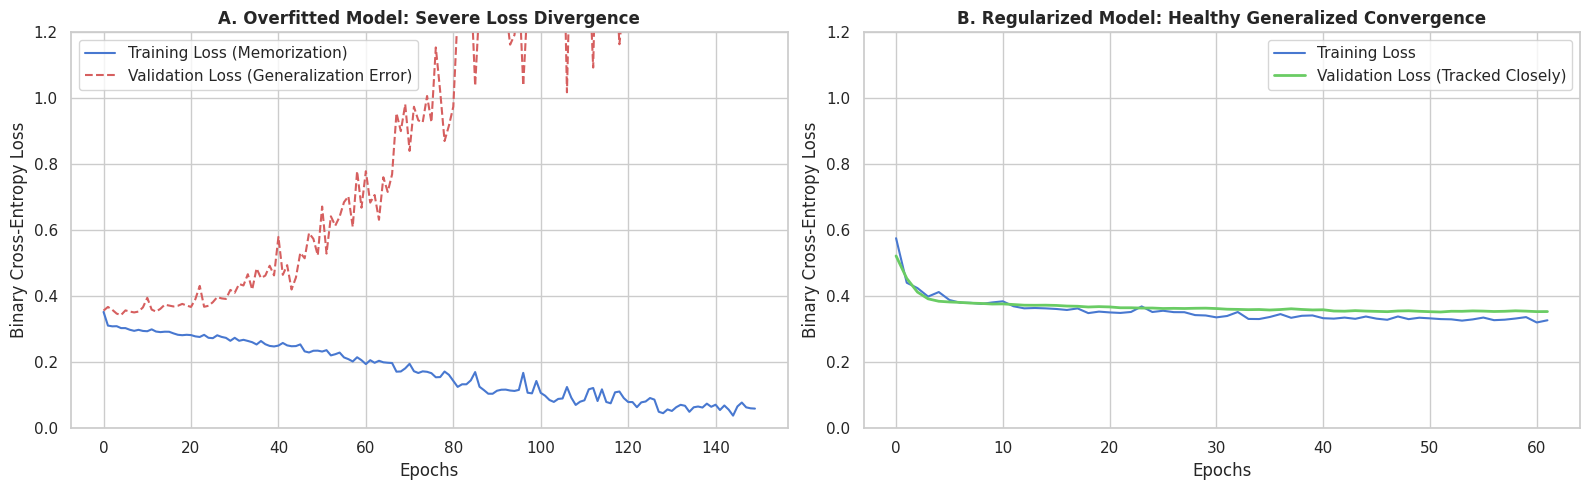

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Overfit Model Test Accuracy:       0.8988 ROC-AUC
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Regularized Model Test Accuracy:   0.9305 ROC-AUC


In [8]:
# ==============================================================================
# SECTION 7: LIVE DEMO — THE OVERFITTING TRAGEDY & THE REGULARIZED FIX
# ==============================================================================
# Prepare Data
X = df_loan.drop(columns=["Default"])
y = df_loan["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize inputs (Mandatory for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------------------------
# 1. THE FLAWED OVERFITTER MODEL
# (Excessive capacity, 150 epochs, no dropout, no early stopping, no regularization)
# ------------------------------------------------------------------------------
overfit_model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

overfit_model.compile(
    optimizer=Adam(learning_rate=0.005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Training Overfitted Neural Network (150 Epochs)...")
history_overfit = overfit_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=150,
    batch_size=32,
    verbose=0
)

# ------------------------------------------------------------------------------
# 2. THE PRODUCTION-GRADE REGULARIZED MODEL
# (Right-sized capacity, BatchNormalization, Dropout(0.3), EarlyStopping)
# ------------------------------------------------------------------------------
regularized_model = Sequential([
    Dense(64, activation="relu", kernel_regularizer=l2(0.001), input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

regularized_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("Training Regularized Neural Network with Early Stopping...")
history_reg = regularized_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# ------------------------------------------------------------------------------
# 3. VISUALIZING THE TRAINING HISTORY CURVES
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overfitted Model Curves
axes[0].plot(history_overfit.history["loss"], "b-", label="Training Loss (Memorization)")
axes[0].plot(history_overfit.history["val_loss"], "r--", label="Validation Loss (Generalization Error)")
axes[0].set_title("A. Overfitted Model: Severe Loss Divergence", fontweight="bold")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].set_ylim(0, 1.2)
axes[0].legend()

# Regularized Model Curves
axes[1].plot(history_reg.history["loss"], "b-", label="Training Loss")
axes[1].plot(history_reg.history["val_loss"], "g-", lw=2, label="Validation Loss (Tracked Closely)")
axes[1].set_title("B. Regularized Model: Healthy Generalized Convergence", fontweight="bold")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Binary Cross-Entropy Loss")
axes[1].set_ylim(0, 1.2)
axes[1].legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 4. FINAL TEST EVALUATION
# ------------------------------------------------------------------------------
test_preds_overfit = (overfit_model.predict(X_test_scaled) >= 0.5).astype(int)
test_preds_reg = (regularized_model.predict(X_test_scaled) >= 0.5).astype(int)

print(f"Overfit Model Test Accuracy:       {roc_auc_score(y_test, overfit_model.predict(X_test_scaled)):.4f} ROC-AUC")
print(f"Regularized Model Test Accuracy:   {roc_auc_score(y_test, regularized_model.predict(X_test_scaled)):.4f} ROC-AUC")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 48)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,729 (6.75 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 96 (384.00 B)

Training Student Neural Network with Early Stopping...
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 6.

Training stopped after 14 epochs (EarlyStopping patience = 8).


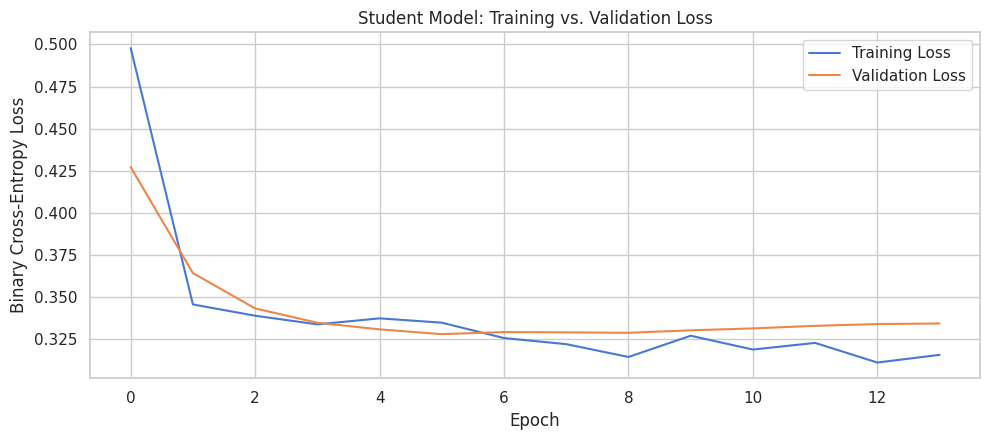

=== CLASSIFICATION REPORT (Test Set) ===
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       310
           1       0.86      0.80      0.83       290

    accuracy                           0.84       600
   macro avg       0.85      0.84      0.84       600
weighted avg       0.84      0.84      0.84       600

ROC-AUC Score: 0.9333


In [10]:
# ==============================================================================
# SECTION 8: STUDENT GRADED LAB ASSIGNMENT
# ==============================================================================
"""
🎓 STUDENT LAB INSTRUCTIONS:
Build, compile, and train your own custom Artificial Neural Network on `loan_default_nn.csv`.

MANDATORY TASKS:
1. Build a Sequential model with:
   - Hidden Layer 1: 48 Neurons, ReLU activation, with input_shape.
   - BatchNormalization layer.
   - Dropout layer (rate = 0.25).
   - Hidden Layer 2: 24 Neurons, ReLU activation.
   - Output Layer: 1 Neuron with Sigmoid activation.
2. Compile using:
   - Optimizer: Adam(learning_rate=0.001)
   - Loss: 'binary_crossentropy'
   - Metrics: ['accuracy']
3. Fit with EarlyStopping (monitor='val_loss', patience=8, restore_best_weights=True)
   over 100 epochs with batch_size=32.
4. Plot the resulting Training vs. Validation Loss curve.
5. Generate and print the test set classification report and ROC-AUC score.
"""

# ------------------------------------------------------------------------------
# STUDENT WORKSPACE (WRITE YOUR SOLUTION BELOW)
# ------------------------------------------------------------------------------

# 1. Model Architecture
student_model = Sequential([

    Dense(48, activation="relu", input_shape=(X_train_scaled.shape[1],)),


    BatchNormalization(),

    Dropout(0.25),


    Dense(24, activation="relu"),

    Dense(1, activation="sigmoid")
])

student_model.summary()

student_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


early_stop_student = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

print("Training Student Neural Network with Early Stopping...")
history_student = student_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_student],
    verbose=0
)

print(f"\nTraining stopped after {len(history_student.history['loss'])} epochs "
      f"(EarlyStopping patience = 8).")

plt.figure(figsize=(10, 4.5))
plt.plot(history_student.history["loss"], label="Training Loss")
plt.plot(history_student.history["val_loss"], label="Validation Loss")
plt.title("Student Model: Training vs. Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.show()


y_pred_proba = student_model.predict(X_test_scaled, verbose=0).ravel()


y_pred_labels = (y_pred_proba >= 0.5).astype(int)

print("=== CLASSIFICATION REPORT (Test Set) ===")
print(classification_report(y_test, y_pred_labels))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")
